# Comparative Cell-Cell Communication with Liana and CrossTalkeR

<a href="https://colab.research.google.com/github/saezlab/liana-py/blob/main/docs/source/notebooks/liana_c2c.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Background

As proposed by [Nagai et al, 2021](https://academic.oup.com/bioinformatics/article/37/22/4263/6275746], condition-specific cell-cell communication can be revealed using node importance measures. By ranking the graph nodes (cell types), we can identify disease-driving cell types and their subsequent ligand-receptor interactions.

pyCrossTalkeR is a Python implementation of the initial CrossTalkeR package. Currently, pyCrossTalker also identifies statistically significant interactions using two main cell-cell communication features: gene expression and proportion.
Here, we demonstrate how Liana can be coupled with CrossTalker to reveal condition-specific patterns.

## Load Packages

Install required packages via pip with the following command:

```python
pip install pycrosstalker
```

In [1]:
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict
from pycrosstalker import tools as cttl
from pycrosstalker import plots as ctpl
%matplotlib inline
from scipy.stats import gmean
import os
sc.logging.print_header()


Package,Version
pandas,2.3.3
scanpy,1.12.1
plotnine,0.15.6
liana,1.7.3
pycrosstalker,2.1.2 (1.0.1)
scipy,1.17.1
Component,Info
Python,"3.13.0 | packaged by conda-forge | (main, Nov 27 2024, 19:18:50) [GCC 13.3.0]"
OS,Linux-5.15.0-179-generic-x86_64-with-glibc2.35
CPU,"16/16 logical CPU cores, x86_64"


## Load & Prep Data 

 As a simple example, we will look at ~25k PBMCs from 8 pooled patient lupus samples, each before and after IFN-beta stimulation ([Kang et al., 2018](https://www.nature.com/articles/nbt.4042); [GSE96583](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583)). Note that by focusing on PBMCs, for the purpose of this tutorial, we assume that coordinated events occur among them.

This dataset is downloaded from a link on Figshare; preprocessed for [pertpy](https://github.com/theislab/pertpy).

In [3]:
# load data as from CCC chapter
adata = li.testing.datasets.kang_2018()

#### Showcase anndata object

In [17]:
adata.obs.head()

,nCount_RNA,nFeature_RNA,tsne1,tsne2,label,cluster,cell_type,replicate,nCount_SCT,nFeature_SCT,integrated_snn_res.0.4,seurat_clusters
index,,,,,,,,,,,,
AAACATACATTTCC-1,3017.0,877,-27.640373,14.966629,ctrl,9,CD14+ Monocytes,patient_1016,1704.0,711,1,1
AAACATACCAGAAA-1,2481.0,713,-27.493646,28.924885,ctrl,9,CD14+ Monocytes,patient_1256,1614.0,662,1,1
AAACATACCATGCA-1,703.0,337,-10.468194,-5.984389,ctrl,3,CD4 T cells,patient_1488,908.0,337,6,6
AAACATACCTCGCT-1,3420.0,850,-24.367997,20.429285,ctrl,9,CD14+ Monocytes,patient_1256,1738.0,653,1,1
AAACATACCTGGTA-1,3158.0,1111,27.952170,24.159738,ctrl,4,Dendritic cells,patient_1039,1857.0,928,12,12


In [18]:
adata.obs["cell_type"].cat.categories

Index(['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'NK cells', 'CD8 T cells',
       'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes'],
      dtype='object')

In [19]:
sample_key = 'sample'
condition_key = 'label'
groupby = 'cell_type'

#### Basic QC

Note that this data has been largely pre-processed & annotated, we refer the user to the [Quality Control](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html) and other relevant chapters from the best-practices book for information about pre-processing and annotation steps.

In [20]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# log1p normalize the data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In addition to the basic QC steps, one needs to ensure that the cell groups on which they run the analysis are well defined, and stable across samples.

#### Show pre-computed UMAP

In [21]:
adata

AnnData object with n_obs × n_vars = 24562 × 15701
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes'
    var: 'name', 'n_cells'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'

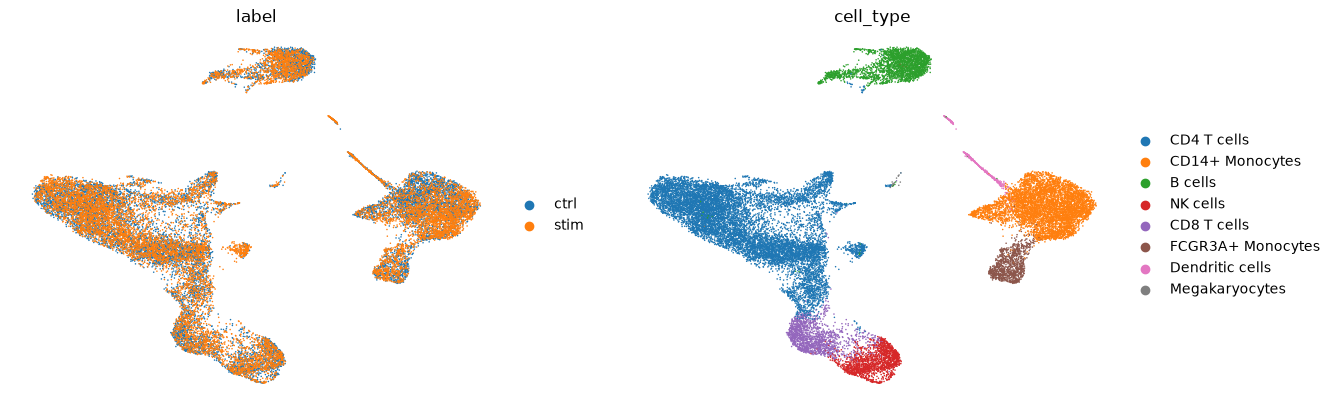

In [22]:
sc.pl.umap(adata, color=[condition_key, groupby], frameon=False)

## Ligand-Receptor Inference by Sample

To compare the effects of stimulation on cell-cell communication, we will first perform ligand-receptor inference using the methods implemented in the `liana` framework, as example of `scseqcomm`.

In [23]:
adata.obsm

AxisArrays with keys: X_pca, X_umap

In [47]:
li.mt.scseqcomm.by_sample(
    adata,
    groupby=groupby,
    resource_name='consensus', # NOTE: uses human gene symbols!
    sample_key=condition_key, # sample key by which we which to loop
    use_raw=False, 
    verbose=True, # use 'full' to show all verbose information
    n_perms=10, # exclude permutations for speed
    return_all_lrs=False# return all LR values
    )

Now running: stim: 100%|█████████████████████████| 2/2 [00:05<00:00,  2.69s/it]


Check results

In [48]:
adata.uns['liana_res'].groupby("label").size()

label
ctrl    1892
stim    1987
dtype: int64

In total, we obtained 1892 interactions for the control samples and 1987 for stimulated interactions. Now, we use `CrossTalkeR` for performing a graph-based differential cell-cell communication analysis

In [49]:
adata = cttl.utils.from_liana(adata,
                              liana_key = "liana_res",
                              compute_means=True,pval_filter=False)
adata = cttl.analise_LR(adata,save=False)

Create a Differential Table
Calculating CCI Ranking
Calculating GCI Ranking
Network Analysis Done
Generating h5ad file with Analysed Results


Now, we can visualize the main differences of cell-cell interaction using the `plot_cci` 

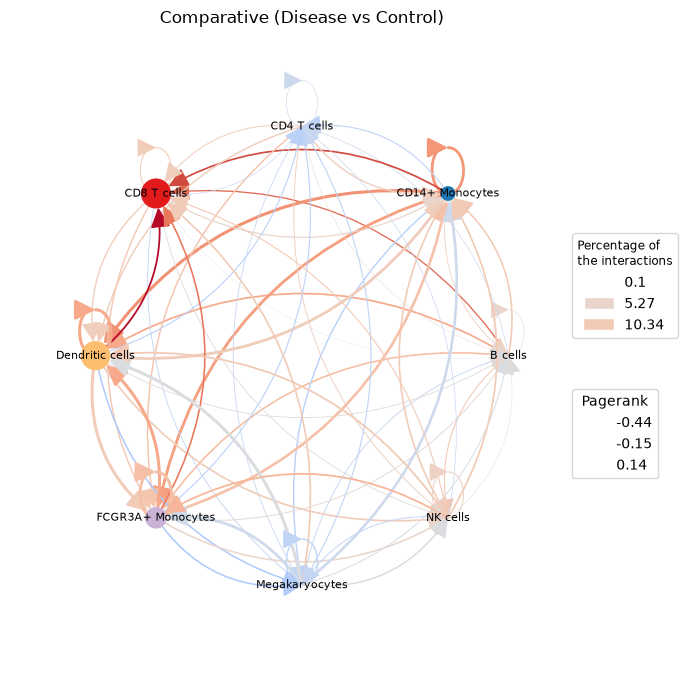

In [50]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["stim_x_ctrl"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Comparative (Disease vs Control)',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0,
        ignore_alpha= False,
        log= False,
        efactor= 2,
        vfactor= 12,
        pg= adata.uns['pycrosstalker']['results']["rankings"]["stim_x_ctrl"]["Pagerank"],
        figsize= (7, 7),
        scale_factor= 2.0,
        node_size=3.0,
        font_size=8,
        )

A feature from `pyCrossTalkeR` is the statistical comparison of cell-cell communication using the number of interactions, here, we show how the number of interactions are different using the amount of LR pairs selected per biology condition.

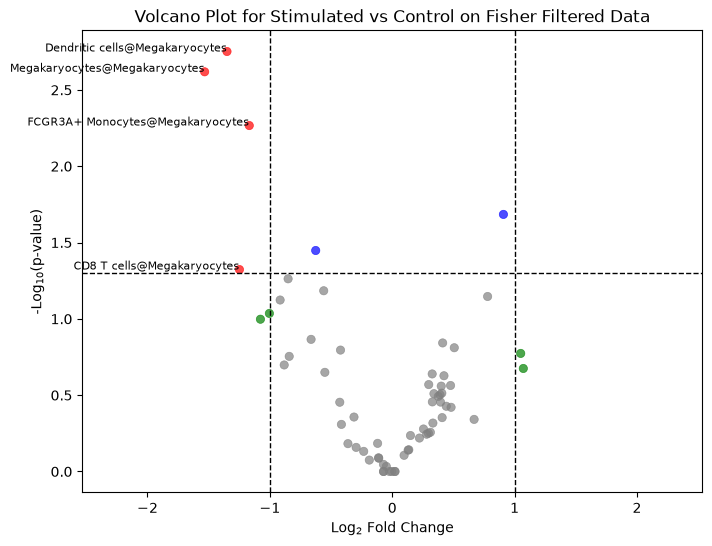

In [32]:
ctpl.plot_volcane(adata.uns['pycrosstalker']['results']['stats']['stim_x_ctrl'], 
                  "fisher", 
                  p_threshold=0.05, 
                  fc_threshold=1, annot=True, title="Volcano Plot for Stimulated vs Control on Fisher Filtered Data")


Using the results of our proportion test, we can see an increase of the interactions from B-Cells to Dentritic Cells. These cells were also related to the IFN stim as shown in the liana-cell2cell notebook.

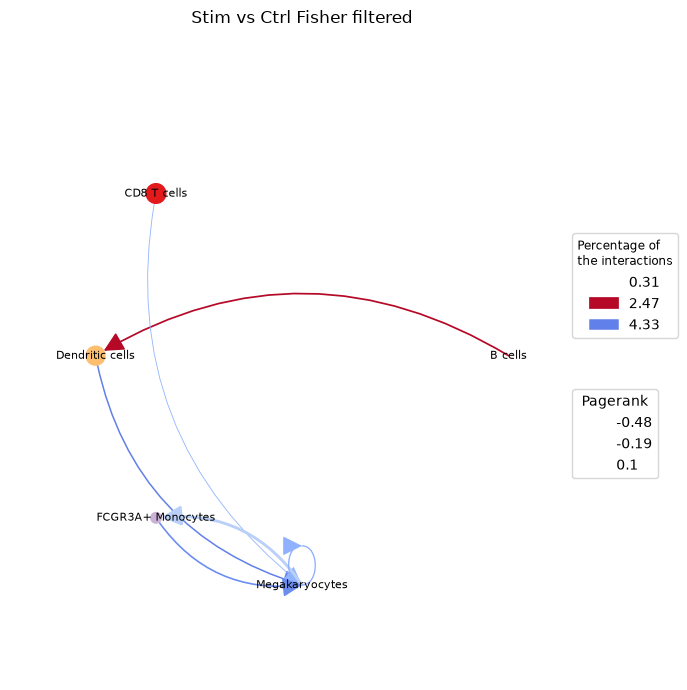

In [60]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["stim_x_ctrl_filtered"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Stim vs Ctrl Fisher filtered',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0,
        ignore_alpha= False,
        log= False,
        efactor= 2,
        vfactor= 12,
        pg= adata.uns['pycrosstalker']['results']["rankings"]["stim_x_ctrl_filtered"]["Pagerank"],
        figsize= (7, 7),
        scale_factor= 2.0,
        node_size=2.0,
        font_size=8,
        )

A feature from `pyCrossTalkeR` is the statistical comparison of cell-cell communication using the expression of interactions, here, we show how the number of interactions are different using the strength of LR pairs selected per biology condition.

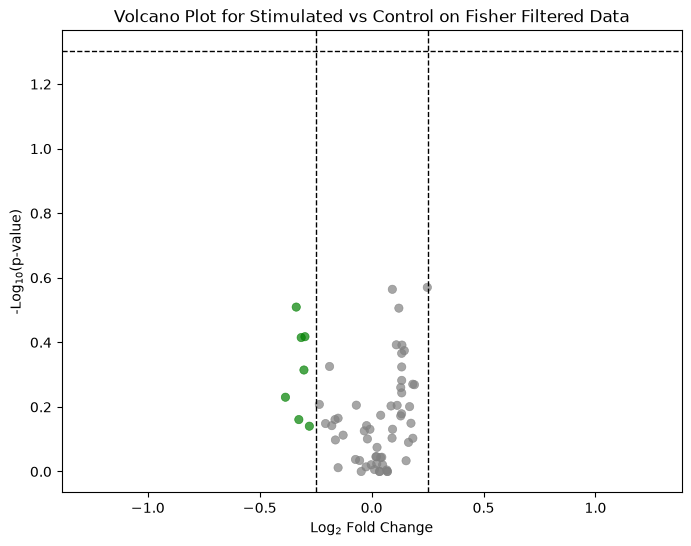

In [58]:
ctpl.plot_volcane(adata.uns['pycrosstalker']['results']['stats']['stim_x_ctrl:MannU'], 
                  "mannwhitneyu", 
                  p_threshold=0.05, 
                  fc_threshold=0.25, annot=True, title="Volcano Plot for Stimulated vs Control on Fisher Filtered Data")


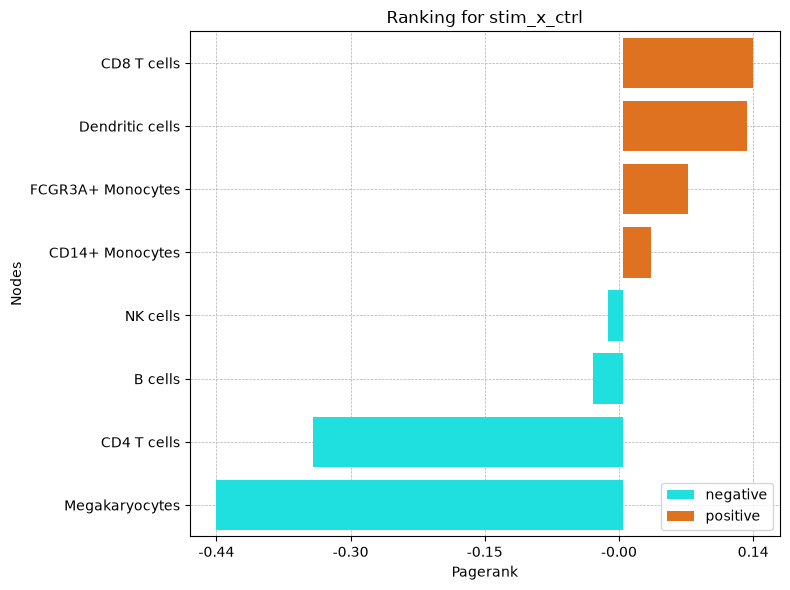

In [52]:
ctpl.plot_bar_rankings(adata, "stim_x_ctrl", "Pagerank")

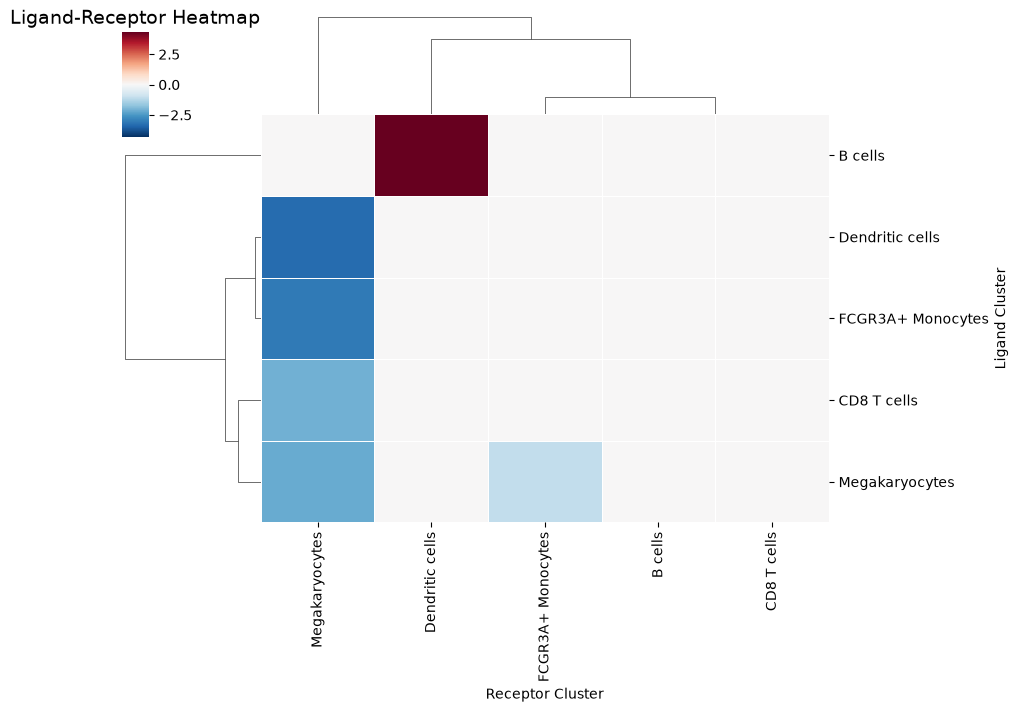

In [53]:
ctpl.plot_graph_clustermap(adata.uns['pycrosstalker']['results']['graphs']['stim_x_ctrl_filtered'], annot=False)


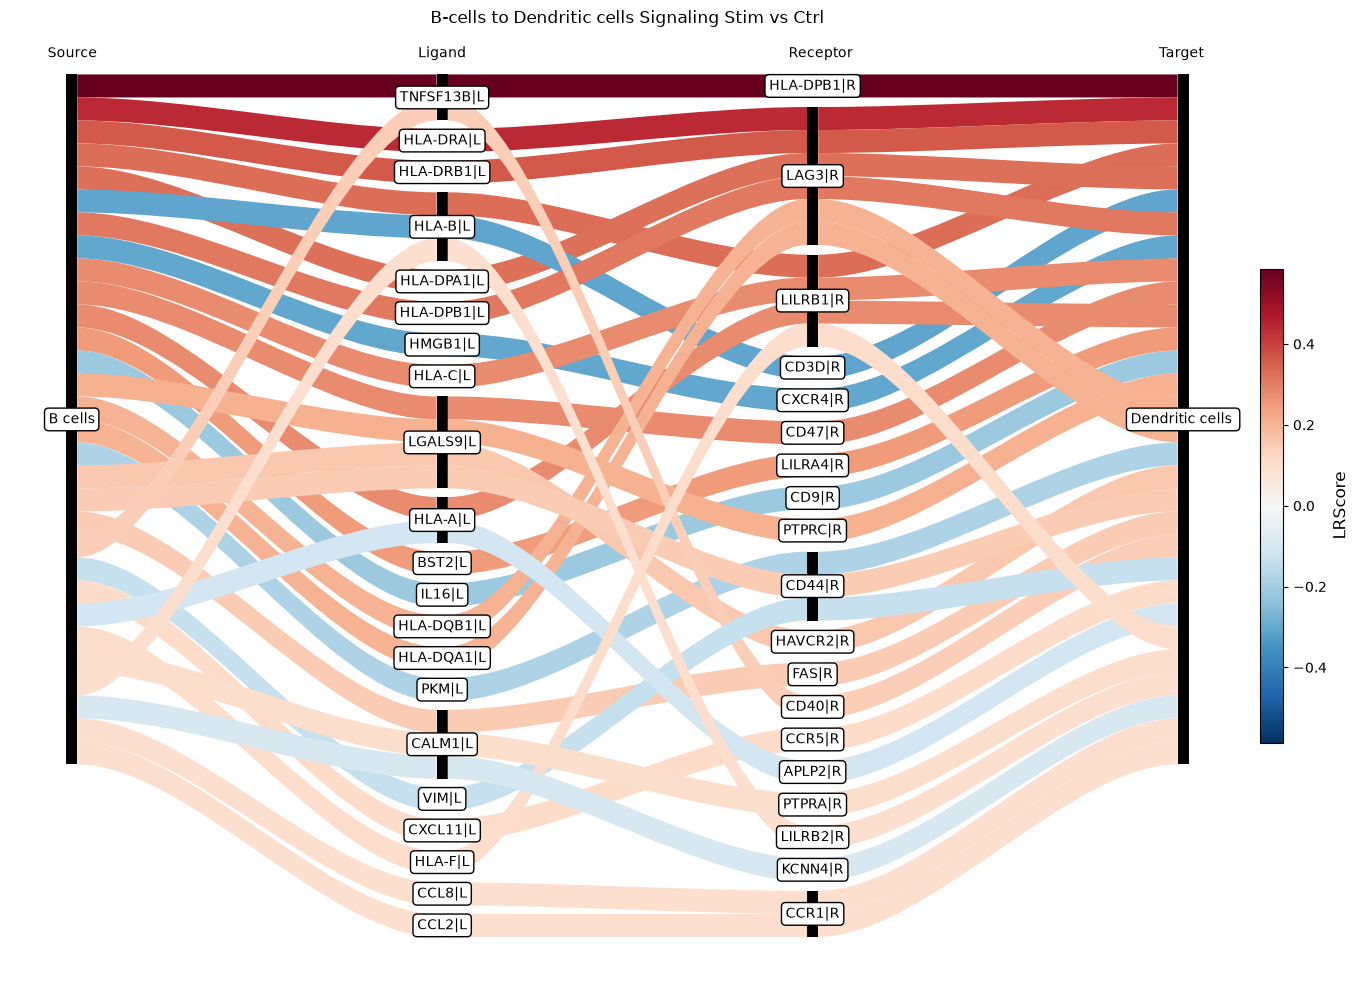

In [54]:
ctpl.plot_sankey(
    adata.uns['pycrosstalker']['results']['tables']['stim_x_ctrl'],
    ligand_cluster = ["B cells"],
    receptor_cluster = ["Dendritic cells"],
    plt_name = "B-cells to Dendritic cells Signaling Stim vs Ctrl",
    threshold = 30)

## Outlook & Further Analysis

There are different ways to explore these results downstream of the pyCrossTalker, these can be further performed using pyCrossTalkeR Tutorial.